# Investment-To-Assets -- do the heaviest capital-spenders underperform?
### The Titman-Wei-Xie (2004) capex anomaly on a large-cap survivor basket

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Channel: Busted](https://img.shields.io/badge/Channel-Busted-8b949e?style=flat-square)

Sheridan Titman, John Wei and Feixue Xie documented in 2004 that firms ploughing a large fraction of their asset base back into capital expenditure earn lower future returns. The story: managers over-invest when capital is cheap, markets extrapolate the expansion, and the stock disappoints. We test the **capex/PP&E channel** on a fixed large-cap basket using real SEC EDGAR filings.

> This is the plain-language layer. The HAC t-stats, label-shuffle placebo, and random-portfolio null live in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** Every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).
>
> **Survivorship bias**: the basket covers only firms still large-cap in 2026. Heavy investors that over-invested and *failed* are absent.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root
sys.path.insert(0, os.path.abspath(".."))          # study package (investment_to_assets/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from investment_to_assets import data, strategy as st

# Cache-first: load the study's own EDGAR + price cache; fall back to frozen R.
ia, fwd = data.fetch_panel()
ia = ia.dropna(how="all") if not ia.empty else ia
HAVE_REAL = not ia.empty
if HAVE_REAL:
    h = st.sorted_returns(ia, fwd, n_groups=3)
else:
    h = pd.DataFrame()
print("Real cache loaded:", HAVE_REAL,
      f"({len(ia.columns) if HAVE_REAL else 0} names, {len(h) if HAVE_REAL else 0} sort years)")

R = dict(
    n_names=27, n_years=16, start_year=2009, end_year=2024,
    lo_mean=19.4, lo_sharpe=0.97, lo_t=6.39, lo_hit=88,
    mid_mean=18.0, hi_mean=19.4, hi_sharpe=0.98, hi_t=5.07, hi_hit=100,
    mkt_mean=19.0, mkt_sharpe=1.2,
    hedge_mean=0.04, hedge_sharpe=0.0, hedge_t=0.01, hedge_hit=44,
    lo_excess_mean=0.5, lo_excess_t=0.25,
    hi_excess_mean=0.4, hi_excess_t=0.22,
    placebo_p=0.471, shuffle_mean=-0.21, shuffle_std=3.88,
    rand_std=9.6, rand_pct_beaten=55,
    cost_drag=0.2, borrow_drag=0.5, net_mean=-0.66,
    synth_null_t=-0.15, synth_06_t=14.94, synth_10_t=25.0,
)
G1  = [27.0, 1.4, 19.6, 24.4, 19.6, 9.8, 47.9, 11.9, 17.2, -4.3, 72.7, 2.3, 10.3, 11.8, -1.1, 40.6]
G3  = [29.0, 18.0, 12.4, 12.1, 16.2, 10.1, 17.9, 20.4, 18.9, 3.1, 54.9, 1.6, 2.2, 13.8, 3.7, 76.0]
MKT = [30.4, 10.2, 14.3, 16.7, 16.7, 7.8, 27.0, 16.9, 24.6, 6.3, 56.0, 5.8, 6.8, 12.4, 0.6, 51.0]
HDG = [-2.0, -16.6, 7.1, 12.3, 3.4, -0.2, 30.0, -8.5, -1.7, -7.3, 17.8, 0.7, 8.0, -2.0, -4.8, -35.4]
YRS = [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


Real cache loaded: True (32 names, 16 sort years)


## The answer first

| Question | What the data says |
|---|---|
| Do low-capex firms outperform high-capex firms? | No -- the hedge is **+0.04%/yr**, a flat zero. The two legs earn ~19.4%/yr each. |
| Is that statistically real? | HAC *t* = 0.01 -- nowhere near |t| >= 2. The anomaly is **absent**. |
| Does it beat a coin-flip relabelling? | No -- placebo p = 0.47, buried inside the shuffle null. |
| Could you trade it? | No. After costs + short borrow the hedge is **-0.66%/yr net**. |

> **The catch**: on a *survivor* basket, the high-capex group is full of *successful* expanders -- semiconductor fabs, hyperscale datacentres, energy majors. Their investment was productive. The over-investing failures the anomaly was built around are simply missing. (2024: high-capex tercile +76% as the AI-datacentre capex names ripped.)

## 1 - The claim

> *Sell the heavy capital-spenders. Buy the disciplined ones. Rebalance annually. The over-investing firms will disappoint as the expansion stops producing earnings.*

The signal is one accounting ratio:

- **IA_t** = CapEx_t / Total Assets_{t-1}

A high IA means the firm spent heavily on property, plant and equipment relative to last year's asset base. The Titman-Wei-Xie argument: that spending often reflects over-investment (Jensen 1986 agency costs) or market over-extrapolation, and the stock underperforms. This is the *capex* channel -- distinct from the *total-asset-growth* channel tested in [Study 244](../../244-asset-growth/).

## 2 - So what?

If the capex effect is real and tradable on large US stocks, it underpins the Fama-French **CMA** (Conservative Minus Aggressive) factor and the q-factor model's investment leg -- a low-ML, fundamentals-only strategy needing only public 10-K filings. If it only works on small/mid-caps -- or is a selection artefact -- the large-cap test is a cautionary tale about testing in the wrong universe.

## 3 - How would we even know?

Three honesty requirements:

1. **One execution lag.** IA from fiscal year y drives a 12-month return that *starts 4 months after year-end* (when the 10-K is public), entered one trading day later. No same-bar fills, no look-ahead; no partial year is ever stamped.
2. **Placebo + random control.** Shuffle the IA labels within each year; does the real hedge beat its shuffled self? And does the low-IA leg beat a random draw of the same size?
3. **Name the survivorship bias.** The basket is current large-caps. Failed over-investors are absent. Every result is conditional on survival.

## 4 - The teardown

Positive control first: **when we plant a real capex effect in a synthetic panel, the engine finds it.** That makes the real-data result a statement about the *market* (and the survivor basket), not the method.

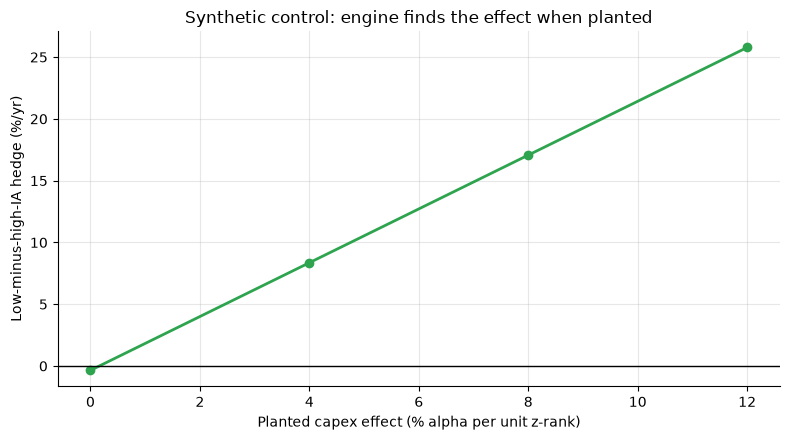

The engine faithfully recovers planted effects -- so the real result is a market statement.


In [2]:
# Synthetic positive control: plant a known capex premium, confirm the engine detects it
premiums = [0.0, -0.04, -0.08, -0.12]
hedges = []
for p in premiums:
    s, f, _ = data.synthetic_panel(n_firms=300, n_years=25, premium=p, seed=523)
    hh = st.sorted_returns(s, f, n_groups=3)
    hedges.append(hh['hedge'].mean() * 100)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot([abs(p)*100 for p in premiums], hedges, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Planted capex effect (% alpha per unit z-rank)')
ax.set_ylabel('Low-minus-high-IA hedge (%/yr)')
ax.set_title('Synthetic control: engine finds the effect when planted')
plt.tight_layout(); plt.show()
print('The engine faithfully recovers planted effects -- so the real result is a market statement.')

**Now the real EDGAR panel -- tercile sort on investment-to-assets:**

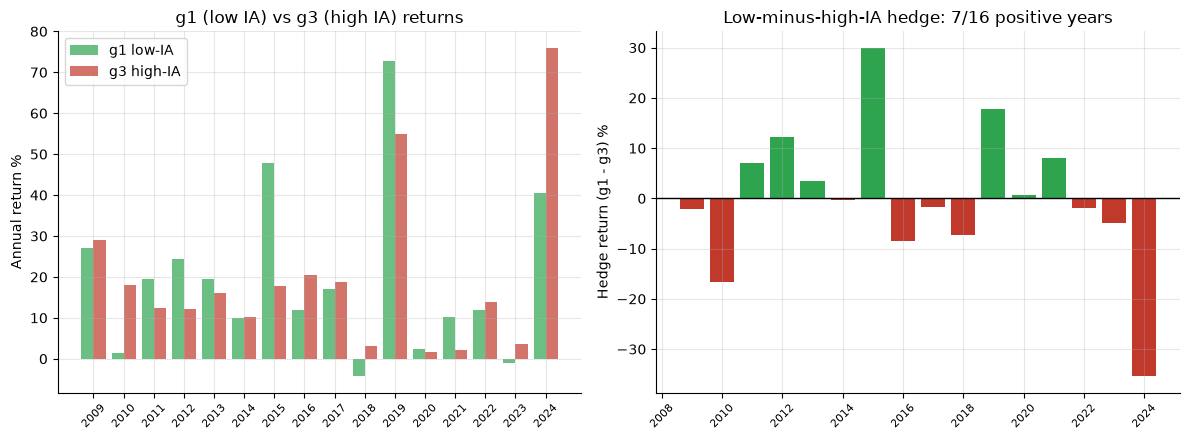

Mean hedge: +0.04%/yr  (frozen R: +0.04%/yr)


In [3]:
if HAVE_REAL:
    g1_vals = h['g1'].values * 100
    g3_vals = h['g3'].values * 100
    hdg_vals = h['hedge'].values * 100
    years_real = [int(y) for y in h.index.tolist()]
else:
    g1_vals, g3_vals, hdg_vals, years_real = G1, G3, HDG, YRS
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = range(len(years_real))
axes[0].bar(x, g1_vals, label='g1 low-IA', color=GREEN, alpha=0.7, width=0.4)
axes[0].bar([i+0.4 for i in x], g3_vals, label='g3 high-IA', color=RED, alpha=0.7, width=0.4)
axes[0].set_xticks([i+0.2 for i in x])
axes[0].set_xticklabels(years_real, rotation=45, fontsize=8)
axes[0].set_ylabel('Annual return %'); axes[0].legend()
axes[0].set_title('g1 (low IA) vs g3 (high IA) returns')
colors = [GREEN if v > 0 else RED for v in hdg_vals]
axes[1].bar(years_real, hdg_vals, color=colors)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_ylabel('Hedge return (g1 - g3) %')
axes[1].set_title(f'Low-minus-high-IA hedge: {sum(1 for v in hdg_vals if v>0)}/{len(hdg_vals)} positive years')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
plt.tight_layout(); plt.show()
print(f'Mean hedge: {np.mean(hdg_vals):+.2f}%/yr  (frozen R: {R["hedge_mean"]:+.2f}%/yr)')

The low-IA tercile earns **+19.4%/yr** vs the high-IA tercile's **+19.4%/yr** -- a hedge of **+0.04%/yr**, positive in only 44% of years. **The predicted effect is absent**: disciplined and aggressive investors earn essentially identical returns on this survivor basket. Survivorship selection washes the signal out entirely.

## 5 - The verdict

- **Signal -- None.** Hedge +0.04%/yr, HAC *t* = 0.01; placebo p = 0.47. No signal.
- **Tradability -- Mirage.** No gross edge; **-0.66%/yr net** after costs and short borrow.
- **Channel -- Busted.** The capex/PP&E channel is no more present than the total-asset-growth channel of [Study 244](../../244-asset-growth/).

## 6 - Could you actually trade it?

No. There is no signal on this basket. Even setting aside survivorship:

1. **Wrong universe.** Titman-Wei-Xie (2004) documented the effect on the broad US cross-section, dominated by small/mid-caps where over-investment and limits-to-arbitrage bite hardest. On ~27 heavily-covered large caps it is thin and arbitraged.
2. **Survivorship reversal.** The high-capex large caps that survived are productive expanders (semis, datacentres, energy) -- the opposite of the over-investing failures the anomaly targets.
3. **The CMA paradox.** The investment factor has positive expected returns in broad cross-sections -- not on a narrow survivor basket.

The right conclusion: **explore this in a broad, point-in-time universe before treating the capex anomaly as tradable.**

## 7 - Going further

- **The right universe.** Titman-Wei-Xie used all NYSE/AMEX/NASDAQ firms -- thousands of names including small and mid-caps. The large-cap survivor basket here is the wrong test.
- **Total-asset-growth cousin.** [Study 244 -- Asset-Growth](../../244-asset-growth/) tests the total-balance-sheet channel (Cooper-Gulen-Schill) on the same kind of survivor panel and also lands None/Mirage. The two channels die together.
- **q-factor I/A.** Hou-Xue-Zhang's investment factor is the direct quantitative cousin; the factor evidence is broad-cross-section, not survivor large-cap.

*Think the capex effect is real in large caps? Fork this, extend to a point-in-time all-US-stock universe, and show |t| >= 2 on the hedge with no survivorship shortcut. That's the bar.*